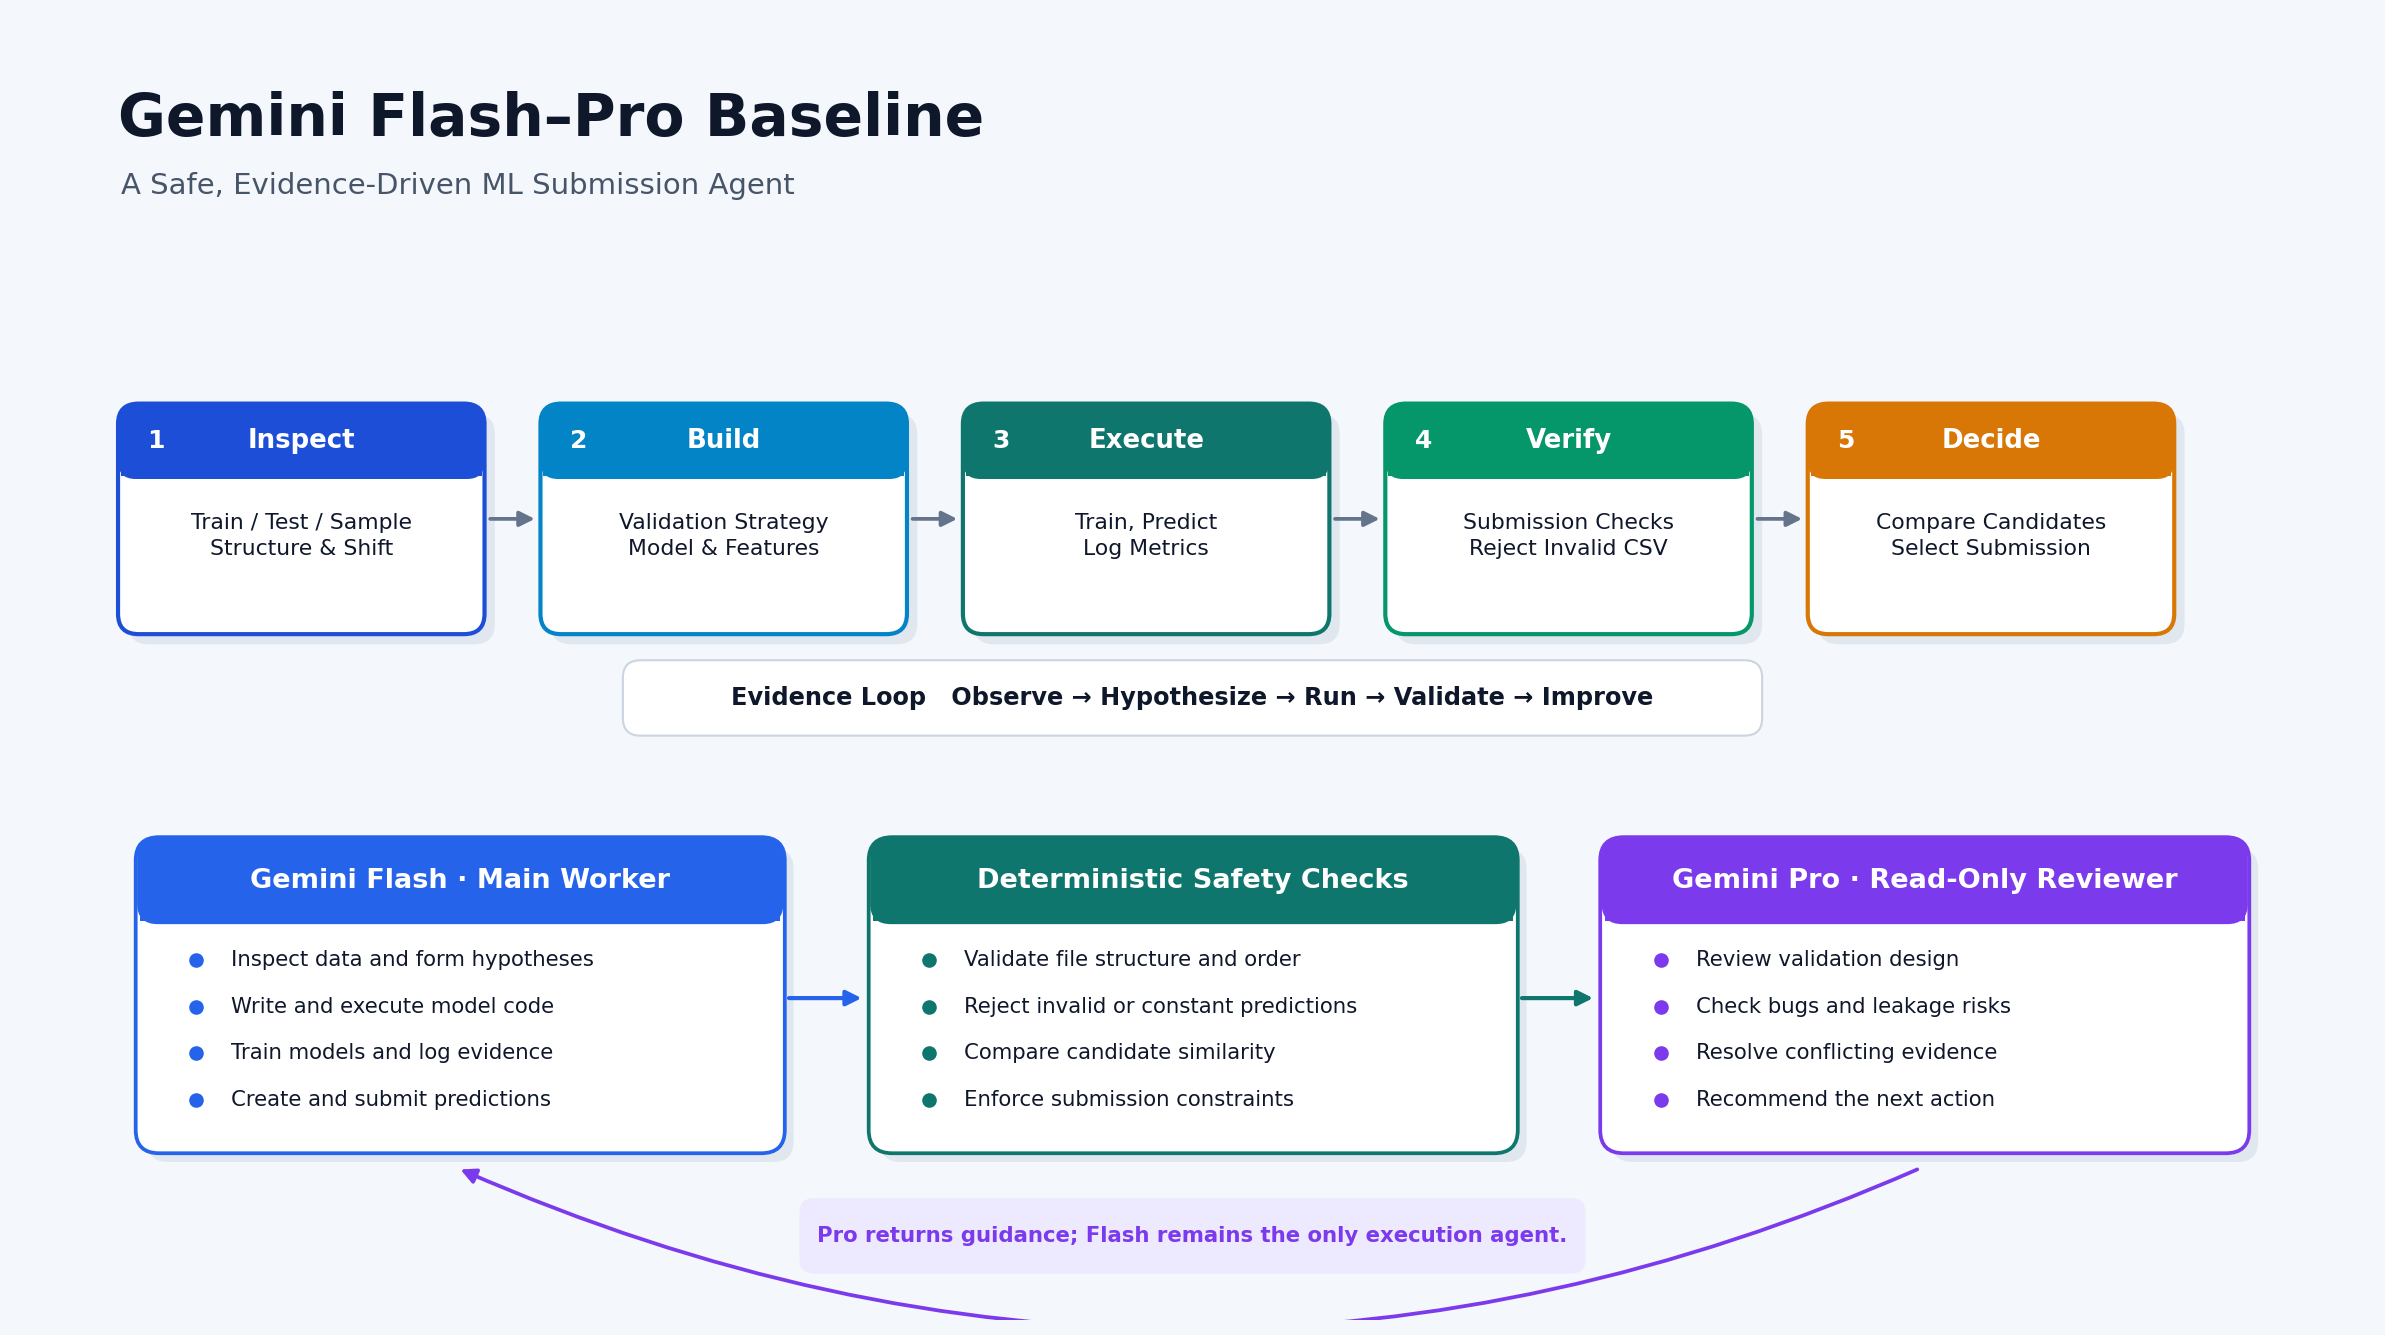

Saved slide image: /kaggle/working/gemini_flash_pro_baseline_colored.png


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

# ------------------------------------------------------------
# Gemini Flash–Pro Baseline
# ------------------------------------------------------------

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

# Color palette
BG = "#F4F7FB"
NAVY = "#0F172A"
MUTED = "#475569"
LINE = "#94A3B8"
WHITE = "#FFFFFF"

FLASH = "#2563EB"
FLASH_LIGHT = "#DBEAFE"

SAFETY = "#0F766E"
SAFETY_LIGHT = "#CCFBF1"

PRO = "#7C3AED"
PRO_LIGHT = "#EDE9FE"

ACCENT = "#F59E0B"
ACCENT_LIGHT = "#FEF3C7"

STAGE_COLORS = [
    ("#1D4ED8", "#DBEAFE"),
    ("#0284C7", "#E0F2FE"),
    ("#0F766E", "#CCFBF1"),
    ("#059669", "#D1FAE5"),
    ("#D97706", "#FEF3C7"),
]

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

# ---------- Helpers ----------
def add_shadow(x, y, w, h, offset=0.07):
    shadow = FancyBboxPatch(
        (x + offset, y - offset), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.14",
        linewidth=0,
        facecolor="#CBD5E1",
        alpha=0.45,
        zorder=1,
    )
    ax.add_patch(shadow)

def add_stage_card(x, y, w, h, number, title, body, border, fill):
    add_shadow(x, y, w, h)

    card = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.14",
        linewidth=2.0,
        edgecolor=border,
        facecolor=WHITE,
        zorder=2,
    )
    ax.add_patch(card)

    header = FancyBboxPatch(
        (x, y + h - 0.48), w, 0.48,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        linewidth=0,
        facecolor=border,
        zorder=3,
    )
    ax.add_patch(header)

    # Cover bottom rounded corners of the header for a cleaner flat separator
    ax.add_patch(Rectangle(
        (x, y + h - 0.48), w, 0.16,
        linewidth=0,
        facecolor=border,
        zorder=3,
    ))

    ax.text(
        x + 0.18, y + h - 0.24,
        f"{number}",
        ha="left", va="center",
        fontsize=12, fontweight="bold",
        color=WHITE, zorder=4
    )
    ax.text(
        x + w / 2, y + h - 0.24,
        title,
        ha="center", va="center",
        fontsize=12.5, fontweight="bold",
        color=WHITE, zorder=4
    )
    ax.text(
        x + w / 2, y + h / 2 - 0.12,
        body,
        ha="center", va="center",
        fontsize=10.5,
        color=NAVY,
        linespacing=1.35,
        zorder=4
    )

def add_role_card(x, y, w, h, title, bullets, color, light):
    add_shadow(x, y, w, h)

    card = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.16",
        linewidth=1.8,
        edgecolor=color,
        facecolor=WHITE,
        zorder=2,
    )
    ax.add_patch(card)

    header = FancyBboxPatch(
        (x, y + h - 0.55), w, 0.55,
        boxstyle="round,pad=0.02,rounding_size=0.14",
        linewidth=0,
        facecolor=color,
        zorder=3,
    )
    ax.add_patch(header)

    ax.add_patch(Rectangle(
        (x, y + h - 0.55), w, 0.18,
        linewidth=0,
        facecolor=color,
        zorder=3,
    ))

    ax.text(
        x + w / 2, y + h - 0.275,
        title,
        ha="center", va="center",
        fontsize=13, fontweight="bold",
        color=WHITE, zorder=4
    )

    body_y = y + h - 0.82
    for i, bullet in enumerate(bullets):
        yy = body_y - i * 0.32
        ax.scatter(
            [x + 0.38], [yy],
            s=36,
            color=color,
            zorder=4
        )
        ax.text(
            x + 0.62, yy,
            bullet,
            ha="left", va="center",
            fontsize=10.2,
            color=NAVY,
            zorder=4
        )

def add_arrow(x1, y1, x2, y2, color=LINE, width=1.8, rad=0):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=width,
        color=color,
        zorder=5
    )
    ax.add_patch(arrow)

# ---------- Header ----------
ax.text(
    0.7, 8.28,
    "Gemini Flash–Pro Baseline",
    fontsize=28,
    fontweight="bold",
    color=NAVY,
    va="center"
)

ax.text(
    0.72, 7.82,
    "A Safe, Evidence-Driven ML Submission Agent",
    fontsize=14,
    color=MUTED,
    va="center"
)

# ---------- Main workflow ----------
pipeline_y = 4.75
box_w = 2.45
box_h = 1.55
gap = 0.42
start_x = 0.72

steps = [
    ("Inspect", "Train / Test / Sample\nStructure & Shift"),
    ("Build", "Validation Strategy\nModel & Features"),
    ("Execute", "Train, Predict\nLog Metrics"),
    ("Verify", "Submission Checks\nReject Invalid CSV"),
    ("Decide", "Compare Candidates\nSelect Submission"),
]

positions = []
for i, ((title, body), (border, fill)) in enumerate(zip(steps, STAGE_COLORS), start=1):
    x = start_x + (i - 1) * (box_w + gap)
    positions.append((x, pipeline_y))
    add_stage_card(x, pipeline_y, box_w, box_h, i, title, body, border, fill)

for i in range(len(positions) - 1):
    x1 = positions[i][0] + box_w + 0.03
    x2 = positions[i + 1][0] - 0.03
    y = pipeline_y + box_h / 2
    add_arrow(x1, y, x2, y, color="#64748B", width=1.8)

# Evidence loop banner
loop_box = FancyBboxPatch(
    (4.15, 4.05), 7.7, 0.48,
    boxstyle="round,pad=0.02,rounding_size=0.12",
    linewidth=1.0,
    edgecolor="#CBD5E1",
    facecolor=WHITE,
    zorder=2
)
ax.add_patch(loop_box)
ax.text(
    8.0, 4.29,
    "Evidence Loop   Observe → Hypothesize → Run → Validate → Improve",
    ha="center", va="center",
    fontsize=11.5,
    fontweight="bold",
    color=NAVY,
    zorder=3
)

# ---------- Roles ----------
add_role_card(
    0.85, 1.18, 4.35, 2.12,
    "Gemini Flash · Main Worker",
    [
        "Inspect data and form hypotheses",
        "Write and execute model code",
        "Train models and log evidence",
        "Create and submit predictions",
    ],
    FLASH,
    FLASH_LIGHT
)

add_role_card(
    5.83, 1.18, 4.35, 2.12,
    "Deterministic Safety Checks",
    [
        "Validate file structure and order",
        "Reject invalid or constant predictions",
        "Compare candidate similarity",
        "Enforce submission constraints",
    ],
    SAFETY,
    SAFETY_LIGHT
)

add_role_card(
    10.8, 1.18, 4.35, 2.12,
    "Gemini Pro · Read-Only Reviewer",
    [
        "Review validation design",
        "Check bugs and leakage risks",
        "Resolve conflicting evidence",
        "Recommend the next action",
    ],
    PRO,
    PRO_LIGHT
)

# Role arrows
add_arrow(5.23, 2.22, 5.78, 2.22, color=FLASH, width=2.0)
add_arrow(10.21, 2.22, 10.75, 2.22, color=SAFETY, width=2.0)

# Feedback loop
add_arrow(
    12.95, 1.05,
    3.0, 1.05,
    color=PRO,
    width=1.8,
    rad=-0.22
)

feedback_box = FancyBboxPatch(
    (5.35, 0.34), 5.3, 0.48,
    boxstyle="round,pad=0.02,rounding_size=0.1",
    linewidth=0,
    facecolor=PRO_LIGHT,
    zorder=2
)
ax.add_patch(feedback_box)
ax.text(
    8.0, 0.58,
    "Pro returns guidance; Flash remains the only execution agent.",
    ha="center", va="center",
    fontsize=10.2,
    fontweight="bold",
    color=PRO,
    zorder=3
)

plt.tight_layout()

output_path = "/kaggle/working/gemini_flash_pro_baseline_colored.png"
plt.savefig(
    output_path,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)
plt.show()

print(f"Saved slide image: {output_path}")


<h2 style="font-size: 28px; font-weight: 700; margin-bottom: 14px;">
Background
</h2>

<p style="font-size: 19px; line-height: 1.6;">
This baseline was inspired by several excellent public Kaggle notebooks and is intended as a simple baseline.
</p>


<p style="font-size: 19px; line-height: 1.6;">
Gemini Flash handles most of the workflow, while Gemini Pro reviews selected results when needed.
</p>



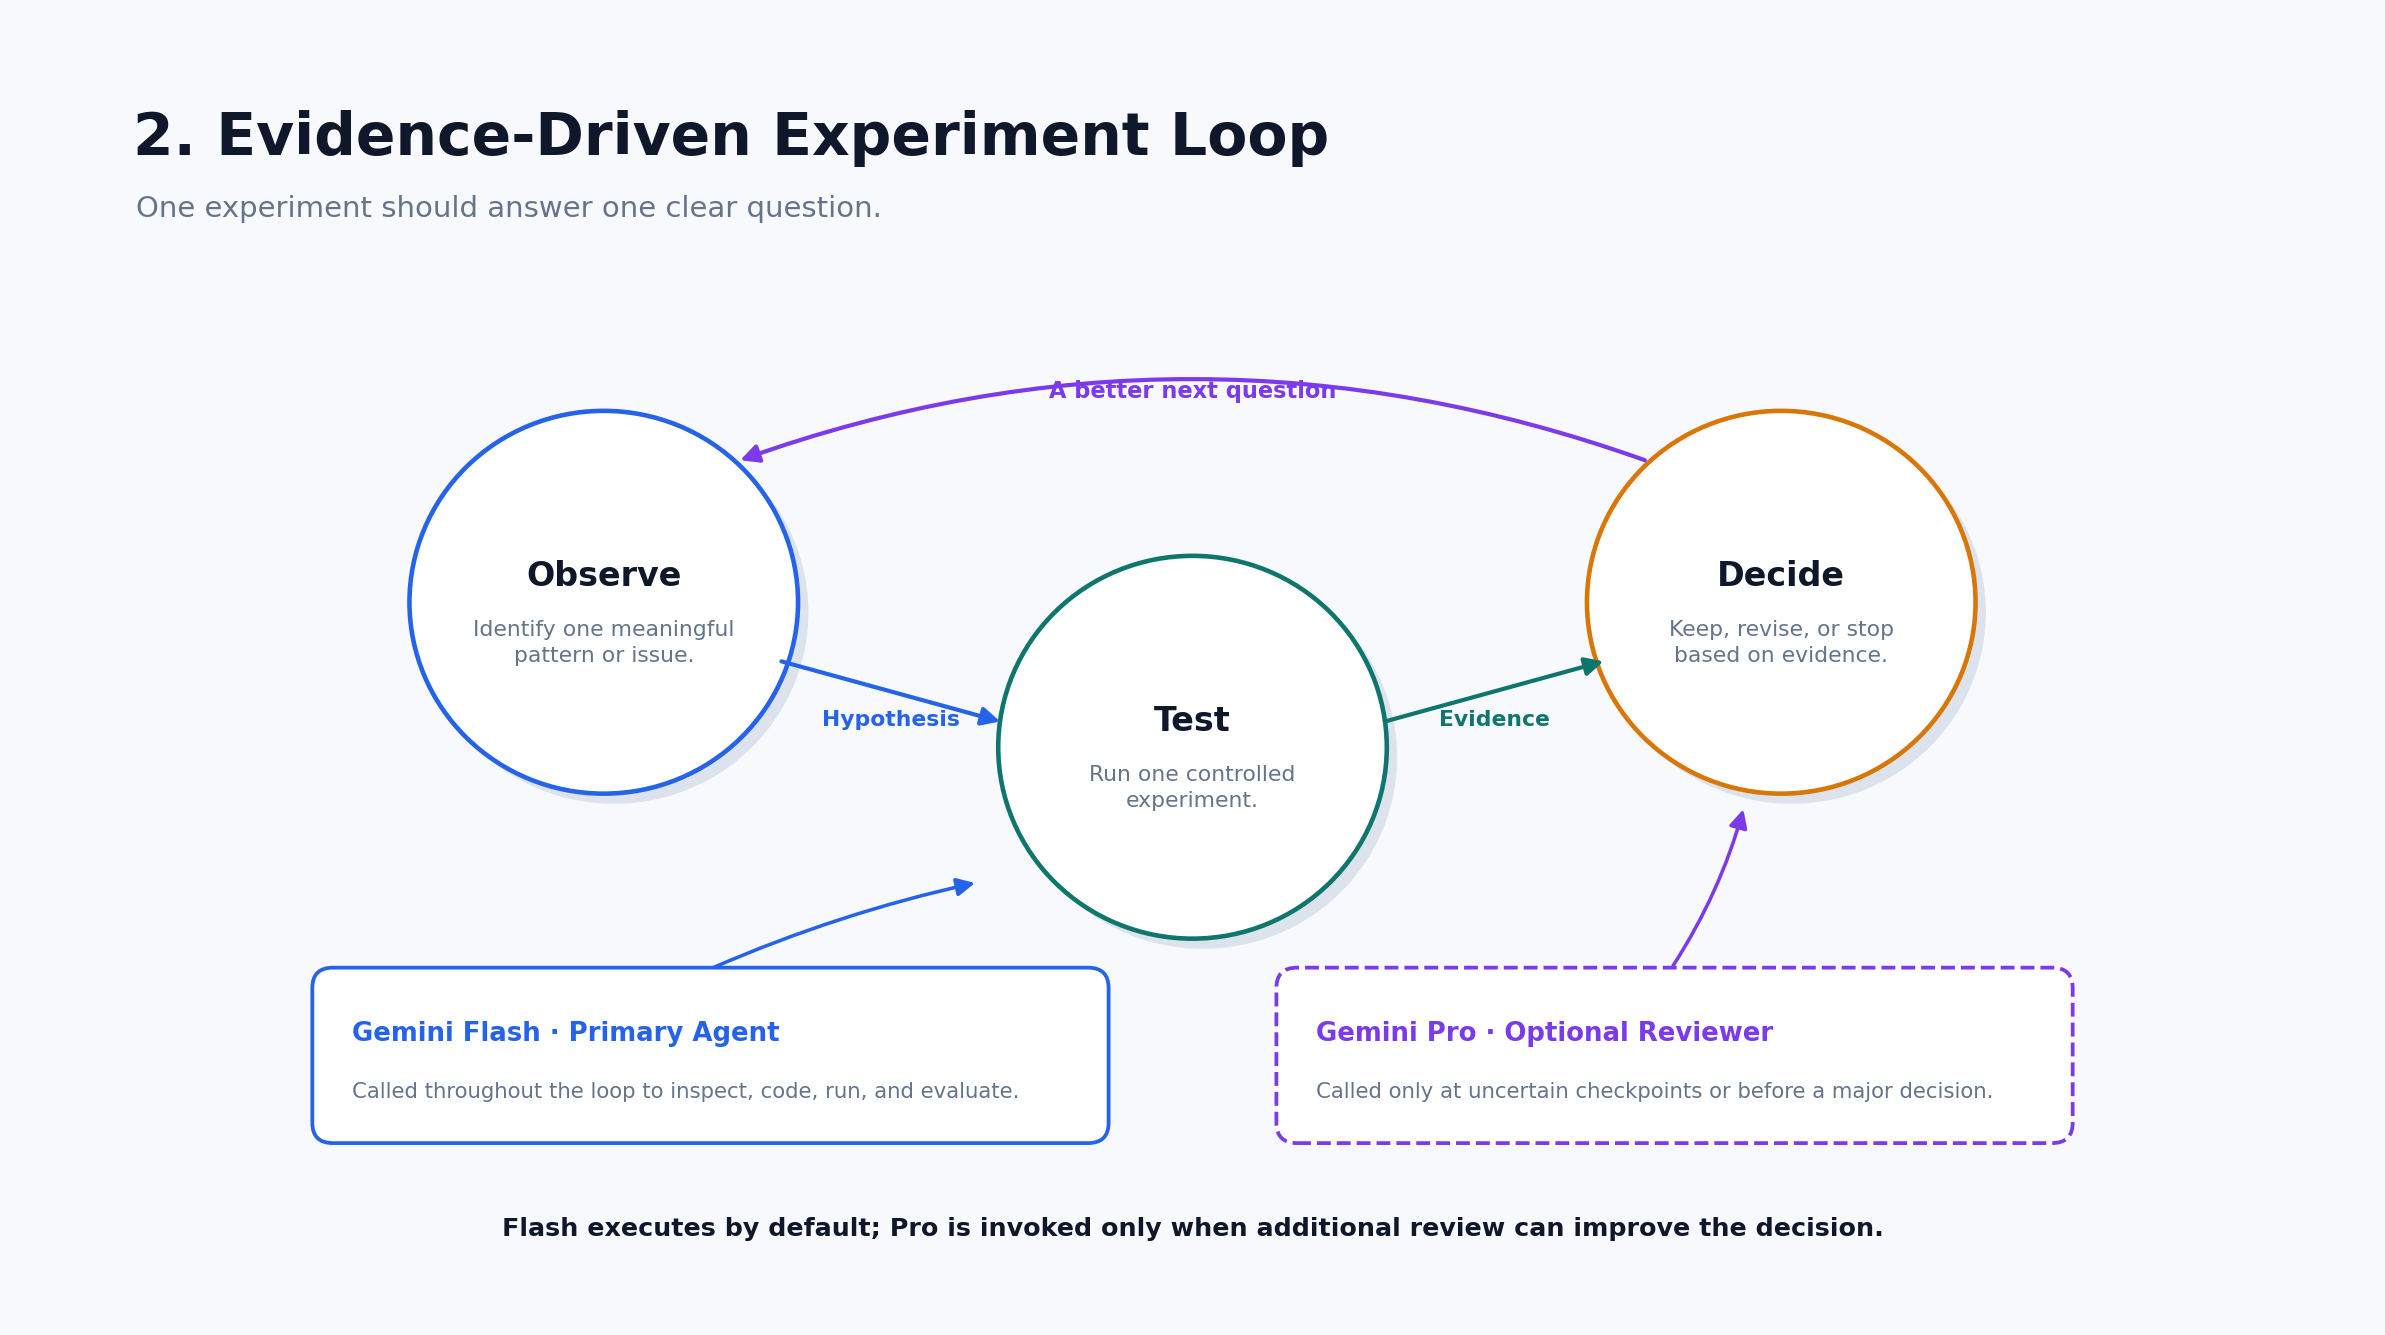

Saved slide image: /kaggle/working/evidence_loop_with_model_calls.png


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

# ============================================================
# 2. Evidence-Driven Experiment Loop
# Minimal model-calling view for Kaggle Notebook
# ============================================================

plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

BG = "#F7F9FC"
TEXT = "#0F172A"
MUTED = "#64748B"
BLUE = "#2563EB"
TEAL = "#0F766E"
AMBER = "#D97706"
PURPLE = "#7C3AED"
LINE = "#94A3B8"
WHITE = "#FFFFFF"

fig, ax = plt.subplots(figsize=(16, 9))

fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")


def add_node(cx, cy, r, color, title, subtitle):
    """Draw one decision-loop node."""

    shadow = Circle(
        (cx + 0.07, cy - 0.07),
        r,
        facecolor="#DCE3EC",
        edgecolor="none",
        zorder=1,
    )
    ax.add_patch(shadow)

    node = Circle(
        (cx, cy),
        r,
        facecolor=WHITE,
        edgecolor=color,
        linewidth=2.2,
        zorder=2,
    )
    ax.add_patch(node)

    ax.text(
        cx,
        cy + 0.18,
        title,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        color=TEXT,
        zorder=3,
    )

    ax.text(
        cx,
        cy - 0.28,
        subtitle,
        ha="center",
        va="center",
        fontsize=10.5,
        color=MUTED,
        linespacing=1.35,
        zorder=3,
    )


def add_arrow(
    x1,
    y1,
    x2,
    y2,
    color=LINE,
    rad=0.0,
    lw=2.0,
):
    """Draw a directional arrow."""

    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=lw,
        color=color,
        zorder=5,
    )
    ax.add_patch(arrow)


def add_model_box(
    x,
    y,
    w,
    h,
    color,
    title,
    subtitle,
    dashed=False,
):
    """Draw a model-role box."""

    linestyle = "--" if dashed else "-"

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.14",
        linewidth=1.8,
        linestyle=linestyle,
        edgecolor=color,
        facecolor=WHITE,
        zorder=2,
    )
    ax.add_patch(box)

    ax.text(
        x + 0.24,
        y + h * 0.63,
        title,
        ha="left",
        va="center",
        fontsize=12.5,
        fontweight="bold",
        color=color,
    )

    ax.text(
        x + 0.24,
        y + h * 0.28,
        subtitle,
        ha="left",
        va="center",
        fontsize=10.2,
        color=MUTED,
    )


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0.8,
    8.15,
    "2. Evidence-Driven Experiment Loop",
    fontsize=28,
    fontweight="bold",
    color=TEXT,
    va="center",
)

ax.text(
    0.82,
    7.66,
    "One experiment should answer one clear question.",
    fontsize=14,
    color=MUTED,
    va="center",
)


# ------------------------------------------------------------
# Decision loop
# ------------------------------------------------------------

radius = 1.32

observe = (4.0, 4.95)
test = (8.0, 3.95)
decide = (12.0, 4.95)

add_node(
    *observe,
    radius,
    BLUE,
    "Observe",
    "Identify one meaningful\npattern or issue.",
)

add_node(
    *test,
    radius,
    TEAL,
    "Test",
    "Run one controlled\nexperiment.",
)

add_node(
    *decide,
    radius,
    AMBER,
    "Decide",
    "Keep, revise, or stop\nbased on evidence.",
)

# Observe → Test
add_arrow(
    5.18,
    4.55,
    6.72,
    4.12,
    color=BLUE,
)

# Test → Decide
add_arrow(
    9.28,
    4.12,
    10.82,
    4.55,
    color=TEAL,
)

# Decide → Observe
add_arrow(
    11.10,
    5.92,
    4.90,
    5.92,
    color=PURPLE,
    rad=0.18,
)

ax.text(
    5.95,
    4.10,
    "Hypothesis",
    fontsize=10.5,
    color=BLUE,
    fontweight="bold",
    ha="center",
)

ax.text(
    10.05,
    4.10,
    "Evidence",
    fontsize=10.5,
    color=TEAL,
    fontweight="bold",
    ha="center",
)

ax.text(
    8.0,
    6.36,
    "A better next question",
    fontsize=10.8,
    color=PURPLE,
    fontweight="bold",
    ha="center",
)


# ------------------------------------------------------------
# Model invocation
# ------------------------------------------------------------

add_model_box(
    2.05,
    1.25,
    5.35,
    1.15,
    BLUE,
    "Gemini Flash · Primary Agent",
    "Called throughout the loop to inspect, code, run, and evaluate.",
)

add_model_box(
    8.60,
    1.25,
    5.35,
    1.15,
    PURPLE,
    "Gemini Pro · Optional Reviewer",
    "Called only at uncertain checkpoints or before a major decision.",
    dashed=True,
)

# Flash supports the execution loop
add_arrow(
    4.72,
    2.42,
    6.55,
    3.02,
    color=BLUE,
    rad=-0.05,
    lw=1.7,
)

# Pro reviews important decisions
add_arrow(
    11.25,
    2.42,
    11.75,
    3.55,
    color=PURPLE,
    rad=0.08,
    lw=1.7,
)


# ------------------------------------------------------------
# Key message
# ------------------------------------------------------------

ax.text(
    8.0,
    0.63,
    (
        "Flash executes by default; Pro is invoked only when "
        "additional review can improve the decision."
    ),
    ha="center",
    va="center",
    fontsize=12.2,
    fontweight="bold",
    color=TEXT,
)


# ------------------------------------------------------------
# Display and save
# ------------------------------------------------------------

plt.tight_layout()

output_path = "/kaggle/working/evidence_loop_with_model_calls.png"

plt.savefig(
    output_path,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print(f"Saved slide image: {output_path}")

<p style="font-size: 19px; line-height: 1.6;">Gemini Flash handles most of the workflow, while Gemini Pro provides final judge-like feedback.</p>

<p style="font-size: 19px; line-height: 1.6;">The baseline minimizes structural bias by avoiding fixed assumptions about the competition data.</p>


# Submission File

### Baseline Package

```text
submission/
├── agent.yaml
│   (Connects all models, prompts, tools, and skills)
│
├── prompts/
│   ├── flash_observe_write_run_submit_instructions.md
│   │   (Defines the main workflow for Gemini Flash)
│   │
│   └── pro_read_pasted_evidence_and_return_next_flash_action.md
│       (Defines the review role of Gemini Pro)
│
├── configs/
│   ├── flash_worker_generation_settings.yaml
│   │   (Controls Gemini Flash generation settings)
│   │
│   └── pro_read_pasted_evidence_and_return_next_action_settings.yaml
│       (Controls Gemini Pro generation settings)
│
├── tools/
│   └── ask_pro_to_return_next_flash_action_for_pasted_evidence.yaml
│       (Allows Flash to request feedback from Pro)
│
└── skills/
    └── inspect-data-and-check-submission-files/
        ├── SKILL.md
        │   (Defines when and how the validation skill is used)
        │
        ├── scripts/
        │   ├── print_train_test_structure_and_shift.py
        │   │   (Inspects data structure and train/test differences)
        │   │
        │   ├── reject_invalid_submission_csv.py
        │   │   (Validates and rejects invalid submissions)
        │   │
        │   └── print_candidate_prediction_similarity.py
        │       (Compares prediction similarity between candidates)
        │
        └── resources/
            └── rules_for_what_file_check_scripts_may_and_may_not_do.md
                (Defines the allowed scope of validation scripts)
```

### Files Created During Execution

```text
work/
├── session_log.md
│   (Records observations, experiments, and decisions)
│
├── model_experiment_*.py
│   (Stores generated model experiments)
│
└── submission_*.csv
    (Stores candidate submission files)
```


In [3]:
from pathlib import Path

ROOT = Path("/kaggle/working/submission")

directories = [
    "configs",
    "prompts",
    "skills/inspect-data-and-check-submission-files",
    "skills/inspect-data-and-check-submission-files/resources",
    "skills/inspect-data-and-check-submission-files/scripts",
    "tools",
]

for directory in directories:
    (ROOT / directory).mkdir(parents=True, exist_ok=True)

print(f"Created package directories under: {ROOT}")

Created package directories under: /kaggle/working/submission


---

### (1) `agent.yaml`

In [4]:
%%writefile /kaggle/working/submission/agent.yaml
name: flash_writes_runs_and_submits_ml_code
model: gemini-3.5-flash
instruction: !include prompts/flash_observe_write_run_submit_instructions.md
tools:
  - run_command
  - write_file
  - edit_file
  - submit_predictions
  - select_submission
  - get_status
  - agent_tool:
      config_path: tools/ask_pro_to_return_next_flash_action_for_pasted_evidence.yaml
skills:
  - skills/inspect-data-and-check-submission-files
generate_content_config: !include configs/flash_worker_generation_settings.yaml

Writing /kaggle/working/submission/agent.yaml


---

### (2) `configs/flash_worker_generation_settings.yaml`

In [5]:
%%writefile /kaggle/working/submission/configs/flash_worker_generation_settings.yaml
temperature: 0.2
max_output_tokens: 8192
thinking_config:
  thinking_budget: 3072
  include_thoughts: false

Writing /kaggle/working/submission/configs/flash_worker_generation_settings.yaml


### (3) `configs/pro_read_pasted_evidence_and_return_next_action_settings.yaml`

In [6]:
%%writefile /kaggle/working/submission/configs/pro_read_pasted_evidence_and_return_next_action_settings.yaml
temperature: 0.0
max_output_tokens: 1800

Writing /kaggle/working/submission/configs/pro_read_pasted_evidence_and_return_next_action_settings.yaml


---

### (4) `prompts/flash_observe_write_run_submit_instructions.md`

In [7]:
%%writefile /kaggle/working/submission/prompts/flash_observe_write_run_submit_instructions.md
# Literal execution model

You are Gemini Flash with API tools. Normal prose has no external effect. A Python code block in prose is not saved and is not executed.

Use the exact tool whose name states the effect:

- `write_file`: create a real file from complete text.
- `edit_file`: change a real existing file.
- `run_command`: execute Python or inspect a file you created and receive stdout/stderr.
- `submit_predictions`: send one already-checked prediction CSV and receive a real submission ID.
- `select_submission`: choose real submission IDs for final scoring.
- `get_status`: receive remaining time, tool calls, submissions, and LLM budget.
- `ask_pro_to_return_next_flash_action_for_pasted_evidence`: send pasted evidence to Gemini Pro and receive one explicit next action. Pro cannot read files or apply changes.

The skill `inspect-data-and-check-submission-files` exposes scripts whose filenames state their exact effects:

- `print_train_test_structure_and_shift.py`
- `reject_invalid_submission_csv.py`
- `print_candidate_prediction_similarity.py`

# Required action sequence

## 1. Print data facts before choosing a model

1. Call `get_status`.
2. Run `print_train_test_structure_and_shift.py` on `train.csv`, `test.csv`, and `sample_submission.csv`.
3. Call `write_file` to create `work/session_log.md` containing concise observed facts and your first testable hypothesis.

Do not inspect `solution.csv`. Do not broadly list directories.

## 2. Create, execute, check, and submit the first trained model

1. Choose the simplest credible model experiment from observed evidence.
2. Call `write_file` to create a complete runnable Python script under `work/`.
3. Call `run_command` to execute that script.
4. When execution fails, read the returned traceback, call `edit_file`, and call `run_command` again.
5. The script must create a prediction CSV from one or more fitted models. It must print the validation split, fold or holdout ROC AUC, aggregate score, runtime, prediction minimum, maximum, mean, standard deviation, and output path.
6. Run `reject_invalid_submission_csv.py` on that prediction CSV.
7. Only when it prints `SUBMISSION_CSV_ACCEPTED_FOR_SUBMIT_TOOL`, call `submit_predictions` and record the returned submission ID.

Never call `submit_predictions` on `sample_submission.csv`, unchanged sample predictions, constant predictions, or predictions not produced by fitted models.

## 3. Choose each later experiment from evidence

After each result, record:

- observed result;
- current hypothesis;
- one reason the next experiment could change the final choice.

Then use `write_file` or `edit_file`, followed by `run_command`. Do not mechanically run a predetermined model list. You choose validation design, preprocessing, features, model family, hyperparameters, ablations, and blending from evidence.

All preprocessing and target-dependent statistics used for validation must be fitted using only the training portion of each split.

## 4. Ask Pro only by pasting enough evidence

Call `ask_pro_to_return_next_flash_action_for_pasted_evidence` only for a genuinely difficult decision. The first line must be one exact request type:

- `REQUEST_TYPE: CHECK_PROPOSED_VALIDATION_AND_NEXT_EXPERIMENT`
- `REQUEST_TYPE: CHECK_PASTED_CODE_AND_TRACEBACK_FOR_BUG_OR_LEAKAGE`
- `REQUEST_TYPE: RESOLVE_CONFLICT_BETWEEN_EXPERIMENT_RESULTS`
- `REQUEST_TYPE: CHECK_FINAL_SUBMISSION_IDS_BEFORE_SELECTION`

For code checking, paste the full traceback, the smallest self-contained relevant code or diff, your current diagnosis, and one exact question. A path alone gives Pro no information.

After Pro returns:

- `USE_CURRENT_WORK_WITHOUT_CHANGES`: continue using your environment tools without applying a Pro-requested change.
- `APPLY_THE_REQUIRED_FIX_AND_RUN_AGAIN`: call `edit_file` or `write_file`, then call `run_command` to verify the fix.
- `STOP_STARTING_NEW_EXPERIMENTS_AND_SELECT_EXISTING_SUBMISSIONS`: do not train another model; verify existing candidates and call `select_submission`.

A Pro response is never the final external action.

## 5. Stop new experiments and select submissions

Do not start new training when remaining time is 8 minutes or less, remaining tool calls are 6 or fewer, LLM budget is critically low, or no specific experiment has meaningful expected information gain.

Before selection:

1. Call `get_status`.
2. Run `reject_invalid_submission_csv.py` for each intended final candidate file.
3. If comparing two or more candidates, run `print_candidate_prediction_similarity.py`.
4. Verify that each candidate has a real submission ID returned by `submit_predictions`.
5. Optionally ask Pro with `REQUEST_TYPE: CHECK_FINAL_SUBMISSION_IDS_BEFORE_SELECTION` and paste candidate evidence and IDs.
6. Call `select_submission` with the selected real IDs.
7. Call `write_file` or `edit_file` to record the final choice in `work/session_log.md`.
8. Call `get_status` once more, then end with a brief factual plaintext summary.

# Non-negotiable restrictions

- Never list, open, read, parse, copy, hash, stat, or otherwise inspect `solution.csv`.
- Use only `train.csv`, `test.csv`, `sample_submission.csv`, and files you create.
- Treat `sample_submission.csv` only as the required column and row-order template.
- Every submitted probability must be numeric, finite, non-constant, within `[0, 1]`, and aligned exactly to sample columns and row order.
- Do not end before at least one trained-model `submit_predictions` call and one successful `select_submission` call with real submission IDs.
- Public scores are noisy secondary evidence, not hidden labels.
- On every non-final turn, call a tool. Plaintext without a tool call ends the session.

Writing /kaggle/working/submission/prompts/flash_observe_write_run_submit_instructions.md


### (5) `prompts/pro_read_pasted_evidence_and_return_next_flash_action.md`

In [8]:
%%writefile /kaggle/working/submission/prompts/pro_read_pasted_evidence_and_return_next_flash_action.md
# What you can and cannot do

You are Gemini Pro. Gemini Flash calls you as a read-only API tool.

You can read only the text pasted into the current tool call. You cannot open a path, read a file, run Python, edit code, submit a CSV, or select a submission. Never claim that you performed any of those actions.

Find the single most important correctness, leakage, validation, or final-selection problem in the pasted evidence. Do not replace the entire ML approach unless the current approach is unusable.

The first line of the request must be exactly one of these explicit request types:

- `REQUEST_TYPE: CHECK_PROPOSED_VALIDATION_AND_NEXT_EXPERIMENT`
- `REQUEST_TYPE: CHECK_PASTED_CODE_AND_TRACEBACK_FOR_BUG_OR_LEAKAGE`
- `REQUEST_TYPE: RESOLVE_CONFLICT_BETWEEN_EXPERIMENT_RESULTS`
- `REQUEST_TYPE: CHECK_FINAL_SUBMISSION_IDS_BEFORE_SELECTION`

# Required response

Return exactly these headings:

NEXT_FLASH_ACTION: <USE_CURRENT_WORK_WITHOUT_CHANGES|APPLY_THE_REQUIRED_FIX_AND_RUN_AGAIN|STOP_STARTING_NEW_EXPERIMENTS_AND_SELECT_EXISTING_SUBMISSIONS>

MOST_IMPORTANT_PROBLEM:
State one evidence-based problem, or `none`.

EXACT_REQUIRED_CHANGE:
State the smallest concrete change Flash must apply, or `none`.

WHY_THIS_ACTION_FOLLOWS_FROM_THE_EVIDENCE:
Give a concise explanation tied to the pasted measurements, traceback, code, or submission evidence.

OPTIONAL_NON_REQUIRED_NOTE:
Give at most one optional idea, or `none`.

The action words have literal effects:

- `USE_CURRENT_WORK_WITHOUT_CHANGES`: Flash should continue its current plan or use the current code without applying a Pro-requested correction.
- `APPLY_THE_REQUIRED_FIX_AND_RUN_AGAIN`: Flash must use `edit_file` or `write_file`, then use `run_command` to verify the change.
- `STOP_STARTING_NEW_EXPERIMENTS_AND_SELECT_EXISTING_SUBMISSIONS`: Flash must stop training new models, verify existing candidate files and real submission IDs, then call `select_submission`. This never means ending with plaintext before selection.

# What to inspect for each request type

## CHECK_PROPOSED_VALIDATION_AND_NEXT_EXPERIMENT

Check whether the proposed split could leak repeated entities, time order, duplicates, or target-derived information. Check whether the proposed experiment can change the stated hypothesis. Prefer one cheap discriminating test over a broad plan.

## CHECK_PASTED_CODE_AND_TRACEBACK_FOR_BUG_OR_LEAKAGE

Inspect only the pasted traceback, code, or diff. Check first for preprocessing fitted outside a fold, target encoding leakage, wrong OOF indices, inconsistent train/test columns, wrong test averaging, misordered submission rows, non-finite predictions, dtype errors, shape errors, path errors, and API errors supported by the traceback.

When a fix is required, give the smallest implementable change. A short replacement code block is allowed inside `EXACT_REQUIRED_CHANGE`, but do not rewrite unrelated code.

## RESOLVE_CONFLICT_BETWEEN_EXPERIMENT_RESULTS

Use the pasted fold scores, score variance, prediction statistics, prediction correlations, runtimes, and public scores. Public score is weak evidence. Return either one low-cost test, continued use of current work, or an instruction to stop new experiments.

## CHECK_FINAL_SUBMISSION_IDS_BEFORE_SELECTION

Check the proposed final candidates for validation mismatch, leakage-like scores, unstable folds, nearly identical prediction vectors, public-score chasing, missing real submission IDs, or unjustified blending. Recommend two candidates only when the second is genuinely complementary.

Writing /kaggle/working/submission/prompts/pro_read_pasted_evidence_and_return_next_flash_action.md


---

### (6) `skills/inspect-data-and-check-submission-files/SKILL.md`

In [9]:
%%writefile /kaggle/working/submission/skills/inspect-data-and-check-submission-files/SKILL.md
---
name: inspect-data-and-check-submission-files
description: >-
  Runs three deterministic file checks whose effects are stated in their filenames:
  print train/test structure and shift, reject an invalid submission CSV, and print
  similarity between candidate prediction CSVs. These scripts never train or choose models.
---

# Exact script effects

The required manifest filename is `SKILL.md`. Use the script filename that exactly states the needed effect.

## `print_train_test_structure_and_shift.py`

**Effect:** prints train/test/sample structure, inferred target and prediction columns, missingness, cardinality, duplicates, identifier-like columns, and basic train/test shift. It optionally writes the same facts to JSON.

Run before writing the first model script:

```python
run_skill_script(
    skill_name="inspect-data-and-check-submission-files",
    script_name="print_train_test_structure_and_shift.py",
    args="--train train.csv --test test.csv --sample sample_submission.csv --output work/train_test_structure_and_shift.json",
)
```

## `reject_invalid_submission_csv.py`

**Effect:** exits with a non-zero status and prints exact errors when a candidate CSV has wrong columns, wrong row count, changed ID/order columns, non-numeric values, non-finite values, probabilities outside `[0, 1]`, effectively constant predictions, or unchanged sample predictions. It prints `SUBMISSION_CSV_ACCEPTED_FOR_SUBMIT_TOOL` only when all checks pass.

Run immediately before every `submit_predictions` call:

```python
run_skill_script(
    skill_name="inspect-data-and-check-submission-files",
    script_name="reject_invalid_submission_csv.py",
    args="--file work/submission_candidate.csv --test test.csv --sample sample_submission.csv",
)
```

## `print_candidate_prediction_similarity.py`

**Effect:** first rejects any invalid candidate using the same checks above, then prints each prediction vector's statistics and pairwise Pearson correlation, Spearman correlation, and mean absolute difference. It does not choose a winner or create a blend.

Run only when two or more already-valid candidates are being considered for final selection:

```python
run_skill_script(
    skill_name="inspect-data-and-check-submission-files",
    script_name="print_candidate_prediction_similarity.py",
    args="--files work/submission_a.csv work/submission_b.csv --test test.csv --sample sample_submission.csv --output work/candidate_prediction_similarity.json",
)
```

## Resource

`resources/rules_for_what_file_check_scripts_may_and_may_not_do.md` states the exact boundary of these scripts.

Writing /kaggle/working/submission/skills/inspect-data-and-check-submission-files/SKILL.md


### (7) `skills/inspect-data-and-check-submission-files/resources/rules_for_what_file_check_scripts_may_and_may_not_do.md`

In [10]:
%%writefile /kaggle/working/submission/skills/inspect-data-and-check-submission-files/resources/rules_for_what_file_check_scripts_may_and_may_not_do.md
# What the file-check scripts may do

They may print or enforce only mechanical file facts:

- allowed input filenames;
- CSV columns and row counts;
- target and prediction-column inference from train/test/sample differences;
- missingness, cardinality, duplicates, identifier-like columns, and simple train/test shift summaries;
- identifier and row-order preservation;
- numeric finiteness and probability range;
- rejection of constant predictions and unchanged sample predictions;
- prediction-vector statistics and pairwise similarity.

# What the file-check scripts must not do

They must not choose or train a model, choose a validation split, create features, tune hyperparameters, order experiments, choose blend weights, call `submit_predictions`, or call `select_submission`. Gemini Flash makes those decisions from evidence.

Writing /kaggle/working/submission/skills/inspect-data-and-check-submission-files/resources/rules_for_what_file_check_scripts_may_and_may_not_do.md


### (8) `skills/inspect-data-and-check-submission-files/scripts/print_candidate_prediction_similarity.py`

In [11]:
%%writefile /kaggle/working/submission/skills/inspect-data-and-check-submission-files/scripts/print_candidate_prediction_similarity.py
#!/usr/bin/env python3
"""Validate and compare candidate prediction vectors without choosing a winner."""

from __future__ import annotations

import argparse
import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

from reject_invalid_submission_csv import infer_submission_columns, inspect_prediction_file


def main() -> None:
    parser = argparse.ArgumentParser(description="Compare prediction CSVs.")
    parser.add_argument("--files", nargs="+", required=True)
    parser.add_argument("--test", default="test.csv")
    parser.add_argument("--sample", default="sample_submission.csv")
    parser.add_argument("--output", default=None)
    args = parser.parse_args()

    test = pd.read_csv(args.test)
    sample = pd.read_csv(args.sample)
    _, prediction_cols = infer_submission_columns(test, sample)
    if len(prediction_cols) != 1:
        raise SystemExit(f"Expected one binary prediction column, inferred: {prediction_cols}")
    pred_col = prediction_cols[0]

    diagnostics: dict[str, Any] = {}
    vectors: dict[str, np.ndarray] = {}
    for file_path in args.files:
        result = inspect_prediction_file(file_path, args.test, args.sample)
        diagnostics[file_path] = result
        if not result["valid"]:
            print(json.dumps({"valid": False, "diagnostics": diagnostics}, indent=2, ensure_ascii=False))
            raise SystemExit(f"Invalid candidate: {file_path}")
        frame = pd.read_csv(file_path)
        vectors[file_path] = pd.to_numeric(frame[pred_col], errors="raise").to_numpy(dtype=float)

    pairwise: list[dict[str, Any]] = []
    names = list(vectors)
    for i, left in enumerate(names):
        for right in names[i + 1 :]:
            a = vectors[left]
            b = vectors[right]
            pearson = float(np.corrcoef(a, b)[0, 1]) if np.std(a) > 0 and np.std(b) > 0 else None
            rank_a = pd.Series(a).rank(method="average").to_numpy()
            rank_b = pd.Series(b).rank(method="average").to_numpy()
            spearman = float(np.corrcoef(rank_a, rank_b)[0, 1]) if np.std(rank_a) > 0 and np.std(rank_b) > 0 else None
            pairwise.append({
                "left": left,
                "right": right,
                "pearson": pearson,
                "spearman": spearman,
                "mean_absolute_difference": float(np.mean(np.abs(a - b))),
            })

    result = {
        "valid": True,
        "prediction_column": pred_col,
        "candidates": diagnostics,
        "pairwise": pairwise,
    }
    text = json.dumps(result, indent=2, ensure_ascii=False, allow_nan=False)
    print(text)
    if args.output:
        output = Path(args.output)
        output.parent.mkdir(parents=True, exist_ok=True)
        output.write_text(text + "\n", encoding="utf-8")
        print(f"CANDIDATE_PREDICTION_SIMILARITY_SAVED: {output}")


if __name__ == "__main__":
    main()

Writing /kaggle/working/submission/skills/inspect-data-and-check-submission-files/scripts/print_candidate_prediction_similarity.py


### (10) `skills/inspect-data-and-check-submission-files/scripts/print_train_test_structure_and_shift.py`

In [12]:
%%writefile /kaggle/working/submission/skills/inspect-data-and-check-submission-files/scripts/print_train_test_structure_and_shift.py
#!/usr/bin/env python3
"""Profile the allowed competition CSVs without imposing an ML strategy."""

from __future__ import annotations

import argparse
import json
import os
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd


def _safe_scalar(value: Any) -> Any:
    if pd.isna(value):
        return None
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return str(value) if not isinstance(value, (str, int, float, bool)) else value


def _column_profile(df: pd.DataFrame) -> dict[str, Any]:
    n = len(df)
    profile: dict[str, Any] = {}
    for col in df.columns:
        s = df[col]
        nunique = int(s.nunique(dropna=True))
        non_null = s.dropna()
        samples = [_safe_scalar(v) for v in non_null.head(3).tolist()]
        profile[str(col)] = {
            "dtype": str(s.dtype),
            "missing": int(s.isna().sum()),
            "missing_rate": float(s.isna().mean()) if n else 0.0,
            "nunique": nunique,
            "unique_rate": float(nunique / max(n, 1)),
            "constant": bool(nunique <= 1),
            "near_unique": bool(n >= 20 and nunique / max(n, 1) >= 0.98),
            "samples": samples,
        }
    return profile


def _series_equal(a: pd.Series, b: pd.Series) -> bool:
    if len(a) != len(b):
        return False
    return a.reset_index(drop=True).equals(b.reset_index(drop=True))


def _infer_columns(train: pd.DataFrame, test: pd.DataFrame, sample: pd.DataFrame) -> dict[str, Any]:
    train_only = [c for c in train.columns if c not in test.columns]
    test_only = [c for c in test.columns if c not in train.columns]
    target = train_only[0] if len(train_only) == 1 else None

    id_cols = [
        c for c in sample.columns
        if c in test.columns and _series_equal(sample[c], test[c])
    ]
    prediction_cols = [c for c in sample.columns if c not in id_cols]
    if not prediction_cols and len(sample.columns) == 1:
        prediction_cols = [sample.columns[0]]

    return {
        "train_only_columns": train_only,
        "test_only_columns": test_only,
        "inferred_target": target,
        "sample_identifier_columns": id_cols,
        "sample_prediction_columns": prediction_cols,
    }


def _duplicate_diagnostics(train: pd.DataFrame, target: str | None) -> dict[str, Any]:
    result: dict[str, Any] = {"exact_duplicate_rows": int(train.duplicated().sum())}
    if target and target in train.columns:
        features = train.drop(columns=[target])
        hashes = pd.util.hash_pandas_object(features, index=False)
        result["duplicate_feature_rows"] = int(hashes.duplicated(keep=False).sum())
        tmp = pd.DataFrame({"h": hashes, "y": train[target]})
        conflicts = tmp.groupby("h", dropna=False)["y"].nunique(dropna=False)
        result["duplicate_feature_groups_with_target_conflict"] = int((conflicts > 1).sum())
    return result


def _numeric_shift(train: pd.DataFrame, test: pd.DataFrame, feature_cols: list[str]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for col in feature_cols:
        if not (pd.api.types.is_numeric_dtype(train[col]) and pd.api.types.is_numeric_dtype(test[col])):
            continue
        tr = pd.to_numeric(train[col], errors="coerce")
        te = pd.to_numeric(test[col], errors="coerce")
        pooled = float(np.nanstd(pd.concat([tr, te], ignore_index=True).to_numpy(dtype=float)))
        mean_diff = float(abs(np.nanmean(tr) - np.nanmean(te)))
        standardized = mean_diff / pooled if pooled > 0 else (0.0 if mean_diff == 0 else float("inf"))
        rows.append({
            "column": str(col),
            "standardized_mean_difference": standardized,
            "train_missing_rate": float(tr.isna().mean()),
            "test_missing_rate": float(te.isna().mean()),
        })
    rows.sort(key=lambda x: x["standardized_mean_difference"], reverse=True)
    return rows[:15]


def _categorical_shift(train: pd.DataFrame, test: pd.DataFrame, feature_cols: list[str]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(train[col]) and pd.api.types.is_numeric_dtype(test[col]):
            continue
        tr_values = set(train[col].dropna().astype(str).unique().tolist())
        te = test[col].dropna().astype(str)
        unseen_rate = float((~te.isin(tr_values)).mean()) if len(te) else 0.0
        rows.append({
            "column": str(col),
            "test_unseen_category_rate": unseen_rate,
            "train_nunique": int(train[col].nunique(dropna=True)),
            "test_nunique": int(test[col].nunique(dropna=True)),
        })
    rows.sort(key=lambda x: x["test_unseen_category_rate"], reverse=True)
    return rows[:15]


def main() -> None:
    parser = argparse.ArgumentParser(description="Profile train/test/sample CSVs.")
    parser.add_argument("--train", default="train.csv")
    parser.add_argument("--test", default="test.csv")
    parser.add_argument("--sample", default="sample_submission.csv")
    parser.add_argument("--output", default=None)
    args = parser.parse_args()

    forbidden = {"solution.csv"}
    for path in (args.train, args.test, args.sample):
        if Path(path).name.lower() in forbidden:
            raise SystemExit("Refusing to inspect solution.csv")
        if not os.path.isfile(path):
            raise SystemExit(f"Required file not found: {path}")

    train = pd.read_csv(args.train)
    test = pd.read_csv(args.test)
    sample = pd.read_csv(args.sample)

    inferred = _infer_columns(train, test, sample)
    target = inferred["inferred_target"]
    feature_cols = [c for c in test.columns if c in train.columns]

    result: dict[str, Any] = {
        "files": {
            "train": {"path": args.train, "bytes": os.path.getsize(args.train), "shape": list(train.shape)},
            "test": {"path": args.test, "bytes": os.path.getsize(args.test), "shape": list(test.shape)},
            "sample": {"path": args.sample, "bytes": os.path.getsize(args.sample), "shape": list(sample.shape)},
        },
        "inference": inferred,
        "train_columns": _column_profile(train),
        "test_columns": _column_profile(test),
        "duplicates": _duplicate_diagnostics(train, target),
        "numeric_shift_top": _numeric_shift(train, test, feature_cols),
        "categorical_shift_top": _categorical_shift(train, test, feature_cols),
    }

    if target and target in train.columns:
        counts = train[target].value_counts(dropna=False)
        result["target"] = {
            "name": target,
            "dtype": str(train[target].dtype),
            "nunique": int(train[target].nunique(dropna=True)),
            "missing": int(train[target].isna().sum()),
            "value_counts": {str(_safe_scalar(k)): int(v) for k, v in counts.head(20).items()},
        }

    text = json.dumps(result, indent=2, ensure_ascii=False, allow_nan=False)
    print(text)
    if args.output:
        output = Path(args.output)
        output.parent.mkdir(parents=True, exist_ok=True)
        output.write_text(text + "\n", encoding="utf-8")
        print(f"TRAIN_TEST_STRUCTURE_AND_SHIFT_SAVED: {output}")


if __name__ == "__main__":
    main()

Writing /kaggle/working/submission/skills/inspect-data-and-check-submission-files/scripts/print_train_test_structure_and_shift.py


### (11) `skills/inspect-data-and-check-submission-files/scripts/reject_invalid_submission_csv.py`


In [13]:
%%writefile /kaggle/working/submission/skills/inspect-data-and-check-submission-files/scripts/reject_invalid_submission_csv.py
#!/usr/bin/env python3
"""Validate a candidate prediction CSV against test and sample submission files."""

from __future__ import annotations

import argparse
import json
import os
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd


def _series_equal(a: pd.Series, b: pd.Series) -> bool:
    return len(a) == len(b) and a.reset_index(drop=True).equals(b.reset_index(drop=True))


def infer_submission_columns(test: pd.DataFrame, sample: pd.DataFrame) -> tuple[list[str], list[str]]:
    id_cols = [c for c in sample.columns if c in test.columns and _series_equal(sample[c], test[c])]
    prediction_cols = [c for c in sample.columns if c not in id_cols]
    if not prediction_cols and len(sample.columns) == 1:
        prediction_cols = [sample.columns[0]]
    return id_cols, prediction_cols


def inspect_prediction_file(file_path: str, test_path: str, sample_path: str) -> dict[str, Any]:
    if Path(file_path).name.lower() == "solution.csv":
        raise ValueError("Refusing to inspect solution.csv")
    for path in (file_path, test_path, sample_path):
        if not os.path.isfile(path):
            raise ValueError(f"File not found: {path}")

    candidate = pd.read_csv(file_path)
    test = pd.read_csv(test_path)
    sample = pd.read_csv(sample_path)

    errors: list[str] = []
    if list(candidate.columns) != list(sample.columns):
        errors.append(f"Column mismatch: candidate={list(candidate.columns)}, sample={list(sample.columns)}")
    if len(candidate) != len(sample):
        errors.append(f"Row-count mismatch: candidate={len(candidate)}, sample={len(sample)}")

    id_cols, prediction_cols = infer_submission_columns(test, sample)
    if not prediction_cols:
        errors.append("Could not infer any prediction column from sample submission")

    for col in id_cols:
        if col in candidate.columns and not _series_equal(candidate[col], sample[col]):
            errors.append(f"Identifier/order column differs from sample: {col}")

    stats: dict[str, Any] = {}
    for col in prediction_cols:
        if col not in candidate.columns:
            continue
        numeric = pd.to_numeric(candidate[col], errors="coerce")
        values = numeric.to_numpy(dtype=float)
        finite = np.isfinite(values)
        unique = int(pd.Series(values[finite]).nunique()) if finite.any() else 0
        std = float(np.std(values[finite])) if finite.any() else float("nan")
        stats[col] = {
            "min": float(np.min(values[finite])) if finite.any() else None,
            "max": float(np.max(values[finite])) if finite.any() else None,
            "mean": float(np.mean(values[finite])) if finite.any() else None,
            "std": std if np.isfinite(std) else None,
            "unique": unique,
        }
        if numeric.isna().any() or not finite.all():
            errors.append(f"Prediction column contains non-numeric or non-finite values: {col}")
        elif np.min(values) < 0 or np.max(values) > 1:
            errors.append(f"Prediction values outside [0, 1]: {col}")
        elif unique <= 1 or std <= 1e-12:
            errors.append(f"Prediction column is constant or effectively constant: {col}")

        if col in sample.columns and _series_equal(candidate[col], sample[col]):
            errors.append(f"Prediction column is unchanged from sample submission: {col}")

    return {
        "valid": not errors,
        "file": file_path,
        "rows": len(candidate),
        "columns": list(candidate.columns),
        "identifier_columns": id_cols,
        "prediction_columns": prediction_cols,
        "prediction_stats": stats,
        "errors": errors,
    }


def main() -> None:
    parser = argparse.ArgumentParser(description="Validate a prediction CSV.")
    parser.add_argument("--file", required=True)
    parser.add_argument("--test", default="test.csv")
    parser.add_argument("--sample", default="sample_submission.csv")
    args = parser.parse_args()

    try:
        result = inspect_prediction_file(args.file, args.test, args.sample)
    except Exception as exc:
        result = {"valid": False, "file": args.file, "errors": [str(exc)]}

    print(json.dumps(result, indent=2, ensure_ascii=False, allow_nan=False))
    if not result.get("valid", False):
        raise SystemExit(1)
    print("SUBMISSION_CSV_ACCEPTED_FOR_SUBMIT_TOOL")


if __name__ == "__main__":
    main()

Writing /kaggle/working/submission/skills/inspect-data-and-check-submission-files/scripts/reject_invalid_submission_csv.py


---

### (12) `tools/ask_pro_to_return_next_flash_action_for_pasted_evidence.yaml`

In [14]:
%%writefile /kaggle/working/submission/tools/ask_pro_to_return_next_flash_action_for_pasted_evidence.yaml
name: ask_pro_to_return_next_flash_action_for_pasted_evidence
description: >-
  Sends only the evidence pasted by Flash to Gemini Pro. Pro cannot read files,
  run commands, edit code, submit predictions, or select submissions. It returns
  one explicit next action for Flash: use the current work unchanged, apply a
  stated fix and run again, or stop new experiments and select existing submissions.
model: gemini-3.1-pro-preview
instruction: !include ../prompts/pro_read_pasted_evidence_and_return_next_flash_action.md
generate_content_config: !include ../configs/pro_read_pasted_evidence_and_return_next_action_settings.yaml

Writing /kaggle/working/submission/tools/ask_pro_to_return_next_flash_action_for_pasted_evidence.yaml


## ZIP FILE

In [15]:
from pathlib import Path
import shutil
import zipfile

source_dir = Path("/kaggle/working/submission")
archive_base = Path("/kaggle/working/submission")

zip_path = shutil.make_archive(
    base_name=str(archive_base),
    format="zip",
    root_dir=source_dir,
)

print(f"Created: {zip_path}")

with zipfile.ZipFile(zip_path) as zf:
    print("\nArchive contents:")
    for name in zf.namelist():
        print(f"  {name}")

Created: /kaggle/working/submission.zip

Archive contents:
  configs/
  prompts/
  skills/
  tools/
  agent.yaml
  configs/pro_read_pasted_evidence_and_return_next_action_settings.yaml
  configs/flash_worker_generation_settings.yaml
  prompts/pro_read_pasted_evidence_and_return_next_flash_action.md
  prompts/flash_observe_write_run_submit_instructions.md
  tools/ask_pro_to_return_next_flash_action_for_pasted_evidence.yaml
  skills/inspect-data-and-check-submission-files/
  skills/inspect-data-and-check-submission-files/resources/
  skills/inspect-data-and-check-submission-files/scripts/
  skills/inspect-data-and-check-submission-files/SKILL.md
  skills/inspect-data-and-check-submission-files/resources/rules_for_what_file_check_scripts_may_and_may_not_do.md
  skills/inspect-data-and-check-submission-files/scripts/reject_invalid_submission_csv.py
  skills/inspect-data-and-check-submission-files/scripts/print_candidate_prediction_similarity.py
  skills/inspect-data-and-check-submission-fi

---

<p style="font-size: 19px; line-height: 1.6;">
To be honest, this baseline still has significant room for improvement.
</p>

<p style="font-size: 19px; line-height: 1.6;">
The core challenge is finding a way to give the LLM greater freedom in how it approaches and solves the problem while maintaining a reliable workflow.
</p>
